# Multivariate Information Theory in Practice

This notebook is a hands-on tutorial covering four Python libraries for
computing information-theoretic measures from data. The material is structured
around **two complementary examples**:

| Example | Purpose |
|---------|---------|
| **Artificial data** | Verify that measures behave as theory predicts on controlled, known systems |
| **Real data** (Wine) | Explore what information-theoretic structure looks like in a real scientific dataset |

### Libraries covered

| Library | Focus | Input type |
|---------|-------|------------|
| **`dit`** | Exact discrete distributions — entropy, MI, TC, co-information | Discrete (PMF) |
| **`hoi`** | Higher-order O-information via KSG estimation | Continuous |
| **`thoi`** | Scalable O-information via Gaussian copula approximation | Continuous |
| **`pyinform`** | Directed information flow in time series (TE, AIS) | Discrete time series |

### Learning objectives
By the end of this notebook you will be able to:
1. Construct a synthetic redundant and synergistic three-variable system.
2. Compute and interpret entropy, total correlation, and co-information with `dit`.
3. Estimate O-information for all multiplets of a dataset with `hoi` and `thoi`.
4. Quantify directed information flow between time series with `pyinform`.
5. Apply these tools to a real dataset and interpret the results.

---
## 1. Theoretical Background

### 1.1 Core quantities

Let $X_1, \ldots, X_n$ be discrete random variables.

| Symbol | Name | Definition |
|--------|------|------------|
| $H(X)$ | Shannon entropy | $-\sum_x p(x)\log_2 p(x)$ |
| $I(X;Y)$ | Mutual information | $H(X)+H(Y)-H(X,Y)$ |
| $TC$ | Total correlation | $\displaystyle\sum_{i=1}^n H(X_i) - H(X_1,\ldots,X_n)$ |
| $DTC$ | Dual total correlation | $H(X_1,\ldots,X_n) - \displaystyle\sum_{i=1}^n H(X_i\mid X_{\setminus i})$ |
| $\Omega$ | O-information | $TC - DTC$ |
| $CI$ | Co-information | Inclusion–exclusion of entropies (equals $\Omega$ for $n=3$) |

### 1.2 O-information as a synergy–redundancy dial

The O-information $\Omega = TC - DTC$ provides a single signed scalar that summarises
the *character* of higher-order statistical structure:

$$\Omega > 0 \;\Rightarrow\; \text{redundancy-dominated} \qquad
\Omega < 0 \;\Rightarrow\; \text{synergy-dominated}$$

### 1.3 Transfer entropy (time-series)

Transfer entropy quantifies how much knowing the past of $X$ reduces
uncertainty about the *next* state of $Y$, beyond what $Y$'s own past already tells us:

$$TE_{X \to Y} = I(Y_{t+1}\,;\,X_{1:t} \mid Y_{1:t})$$

$TE_{X\to Y} \neq TE_{Y\to X}$ in general — this asymmetry is what makes TE
useful for detecting **causal direction**.

**Active Information Storage (AIS)** measures how much of a process's own past
is used to produce its next state: $AIS = I(Y_{t+1}\,;\,Y_{1:t})$.

---
## 2. Setup

All imports are collected here. Run this cell first.

> **Environment**: activate the `mithic-workshop` conda environment and install
> the kernel with `python -m ipykernel install --user --name mithic-workshop`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from numpy import random

# sklearn utilities
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from sklearn.datasets import load_wine
from sklearn.feature_selection import mutual_info_classif

# dit — discrete information theory
import dit
from dit import Distribution
from dit.shannon import entropy
from dit.multivariate import total_correlation, coinformation

# hoi — higher-order information
from hoi.metrics import Oinfo, TC, DTC

# pyinform — time-series information dynamics
from pyinform.transferentropy import transfer_entropy
from pyinform.activeinfo import active_info

# thoi — scalable Gaussian copula O-information (requires torch)
from thoi.measures.gaussian_copula import multi_order_measures

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
print('All imports OK.')

c:\Users\cyril\.conda\envs\mithic-workshop\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK.


---
## 3. Artificial Data

We construct two three-variable systems whose O-information sign we can predict
*before* computing anything — these serve as a **sanity check** for every library.

| Dataset | Construction | Expected $\Omega$ | Reason |
|---------|-------------|-------------------|--------|
| `data_red` | $X_1 \approx X_2 \approx X_0$ (copies with small noise) | $> 0$ | All three variables carry the same information |
| `data_syn` | $X_2 = X_0 + X_1 + \varepsilon$ | $< 0$ | $X_2$ is only informative *jointly* with $X_0$ and $X_1$ |

The noise level $\varepsilon = 0.1$ keeps the signal-to-noise ratio high so the
discrete estimators can detect the structure reliably.

### 3.1 Redundant dataset

In [78]:
n_features, n_samples = 3, 500
eta = 0.1

# One underlying source copied to all three variables
data_red = np.zeros((n_features, n_samples))
copy_variable = random.normal(loc=0.0, scale=1.0, size=n_samples)

data_red[0] = copy_variable
data_red[1] = copy_variable + random.normal(0.0, 1.0, n_samples) * eta
data_red[2] = copy_variable + random.normal(0.0, 1.0, n_samples) * eta

print('data_red shape:', data_red.shape)
print('Pairwise correlations (expected ~1.0):')
print(np.round(np.corrcoef(data_red), 3))

data_red shape: (3, 500)
Pairwise correlations (expected ~1.0):
[[1.    0.995 0.995]
 [0.995 1.    0.99 ]
 [0.995 0.99  1.   ]]


### 3.2 Synergistic dataset

In [90]:
# Two independent sources; third variable is their sum
data_syn = np.zeros((n_features, n_samples))
copy_variable1 = random.normal(0.0, 1.0, n_samples)
copy_variable2 = random.normal(0.0, 1.0, n_samples)

data_syn[0] = copy_variable1 + random.normal(0.0, 1.0, n_samples) * eta
data_syn[1] = copy_variable2 + random.normal(0.0, 1.0, n_samples) * eta
data_syn[2] = copy_variable1 + copy_variable2 + random.normal(0.0, 1.0, n_samples) * eta

print('data_syn shape:', data_syn.shape)
print('Pairwise correlations (X0,X1 independent; X2 correlated with both):')
print(np.round(np.corrcoef(data_syn), 3))

data_syn shape: (3, 500)
Pairwise correlations (X0,X1 independent; X2 correlated with both):
[[1.    0.    0.706]
 [0.    1.    0.697]
 [0.706 0.697 1.   ]]


### 3.3 Visualisation

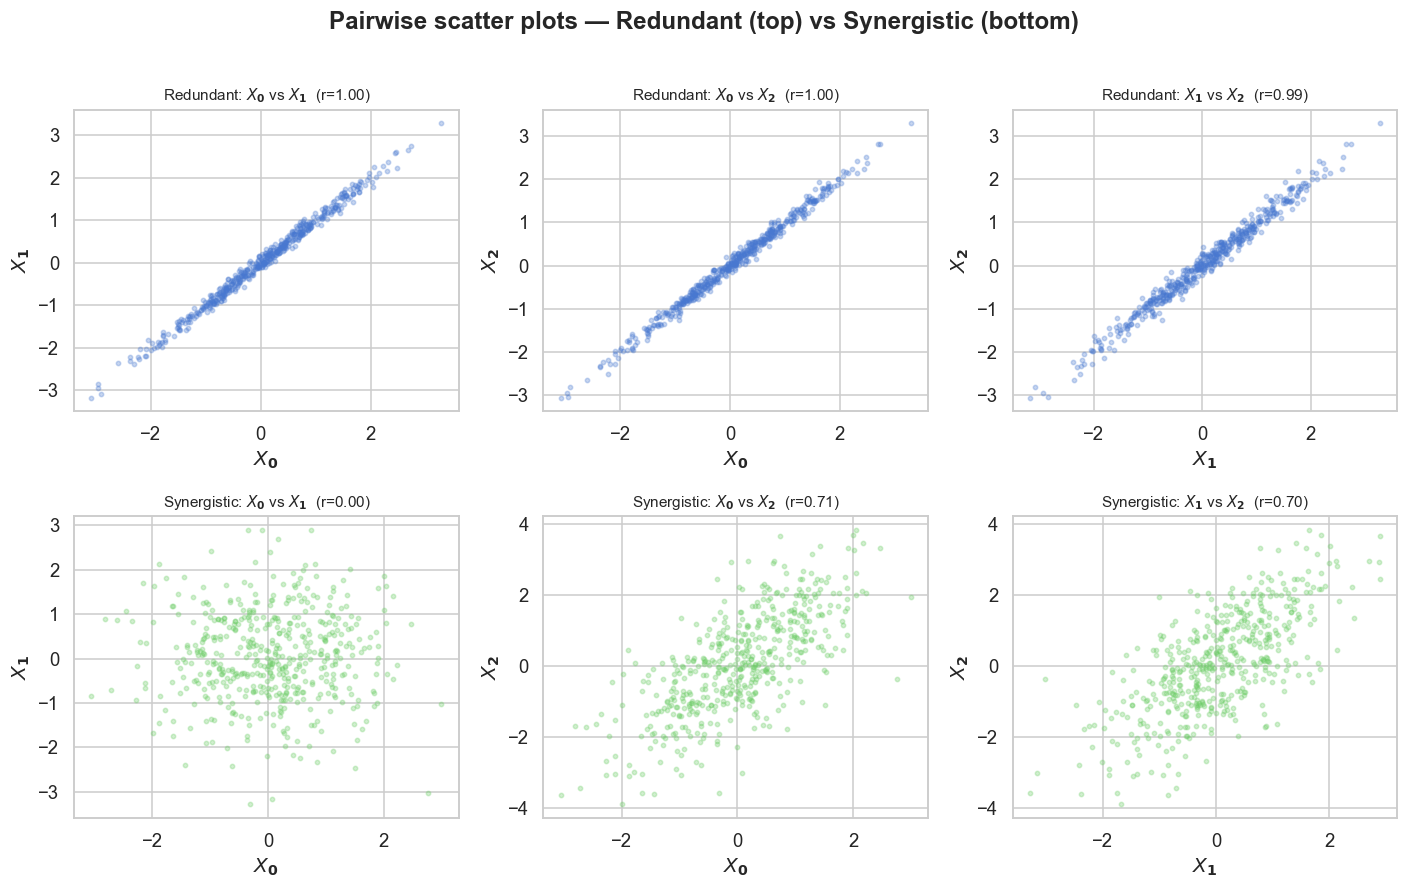

Key observation:
  Redundant: all three pairs tightly correlated → shared information.
  Synergistic: X0,X1 are independent, yet both correlate with X2 → unique joint info.


In [91]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))

# ── Redundant row ─────────────────────────────────────────────────────
pairs_red = [(0,1), (0,2), (1,2)]
for ax, (i, j) in zip(axes[0], pairs_red):
    ax.scatter(data_red[i], data_red[j], alpha=0.3, s=8, color=sns.color_palette()[0])
    r = np.corrcoef(data_red[i], data_red[j])[0,1]
    ax.set_title(f'Redundant: $X_{i}$ vs $X_{j}$  (r={r:.2f})', fontsize=10)
    ax.set_xlabel(f'$X_{i}$'); ax.set_ylabel(f'$X_{j}$')

# ── Synergistic row ───────────────────────────────────────────────────
pairs_syn = [(0,1), (0,2), (1,2)]
for ax, (i, j) in zip(axes[1], pairs_syn):
    ax.scatter(data_syn[i], data_syn[j], alpha=0.3, s=8, color=sns.color_palette()[2])
    r = np.corrcoef(data_syn[i], data_syn[j])[0,1]
    ax.set_title(f'Synergistic: $X_{i}$ vs $X_{j}$  (r={r:.2f})', fontsize=10)
    ax.set_xlabel(f'$X_{i}$'); ax.set_ylabel(f'$X_{j}$')

fig.suptitle('Pairwise scatter plots — Redundant (top) vs Synergistic (bottom)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Key observation:")
print("  Redundant: all three pairs tightly correlated → shared information.")
print("  Synergistic: X0,X1 are independent, yet both correlate with X2 → unique joint info.")

---
## 4. Discretisation

Both `dit` and `pyinform` require **discrete integer-valued** inputs.
We bin each variable independently into $k$ equal-frequency (quantile) bins.

> **Practical note**: The probability distribution, and thus the information measures, can be highly dependent on the choice of k. The main trade-off is resolution vs. stability of the probability estimates: more bins give finer resolution but noisier counts per bin. We use $k=10$ here, but feel free to experiment with different values.

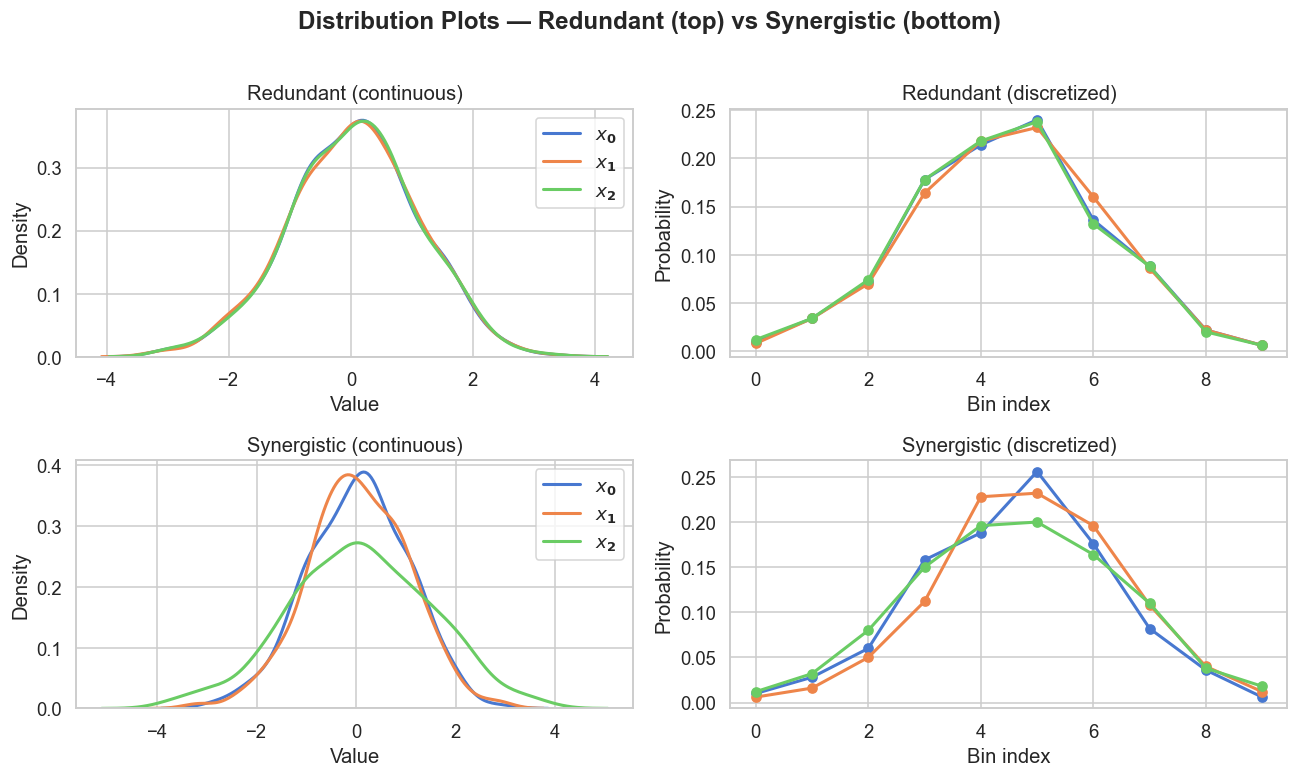

In [92]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer

# Discretisation
def discretize(data, n_bins=10):
    est = KBinsDiscretizer(
        n_bins=n_bins,
        encode='ordinal',
        strategy='uniform'
    )
    return est.fit_transform(data.T).astype(int)

# Plot function: continuous + discrete
def plot_continuous_vs_discrete(data, disc, title, n_bins):
    """
    data: (n_features, n_samples)
    disc: (n_samples, n_features)
    """
    n_features = data.shape[0]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # -------------------------
    # LEFT: continuous KDE
    # -------------------------
    ax = axes[0]
    for i in range(n_features):
        sns.kdeplot(data[i], ax=ax, linewidth=2, label=f"$x_{i}$")

    ax.set_title(f"{title} (continuous)")
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend()

    # -------------------------
    # RIGHT: discretized approx
    # -------------------------
    ax = axes[1]

    for i in range(n_features):
        counts = np.bincount(disc[:, i], minlength=n_bins)
        probs = counts / counts.sum()

        ax.plot(
            np.arange(n_bins),
            probs,
            marker='o',
            linewidth=2,
            label=f"$x_{i}$"
        )

    ax.set_title(f"{title} (discretized, uniform bins)")
    ax.set_xlabel("Bin index")
    ax.set_ylabel("Probability")
    ax.legend()

    plt.tight_layout()
    plt.show()

# Run pipeline
N_BINS = 10

red_disc = discretize(data_red, N_BINS)
syn_disc = discretize(data_syn, N_BINS)

# Combined figure (2 rows, 2 cols)
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

def plot_row(ax_kde, ax_disc, data, disc, title, n_bins):
    # KDE
    for i in range(data.shape[0]):
        sns.kdeplot(data[i], ax=ax_kde, linewidth=2, label=f"$x_{i}$")

    ax_kde.set_title(f"{title} (continuous)")
    ax_kde.set_xlabel("Value")
    ax_kde.set_ylabel("Density")

    # Discrete
    for i in range(data.shape[0]):
        counts = np.bincount(disc[:, i], minlength=n_bins)
        probs = counts / counts.sum()

        ax_disc.plot(
            np.arange(n_bins),
            probs,
            marker='o',
            linewidth=2,
            label=f"$x_{i}$"
        )

    ax_disc.set_title(f"{title} (discretized)")
    ax_disc.set_xlabel("Bin index")
    ax_disc.set_ylabel("Probability")

plot_row(axes[0, 0], axes[0, 1], data_red, red_disc, "Redundant", N_BINS)
plot_row(axes[1, 0], axes[1, 1], data_syn, syn_disc, "Synergistic", N_BINS)
axes[0, 0].legend()
axes[1, 0].legend()
fig.suptitle('Distribution Plots — Redundant (top) vs Synergistic (bottom)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Exact Discrete Information Theory with `dit`

`dit` works with **explicit probability distributions** over joint outcomes.
This gives exact (plugin-estimated) answers rather than KSG approximations.
It is ideal for small-alphabet, small-sample problems.

> **Docs**: https://dit.readthedocs.io

### 5.1 Building a joint distribution

We count how often each outcome tuple $(x_0, x_1, x_2)$ appears
and normalise to get a PMF.

In [97]:
def create_distribution(disc_data):
    '''
    Build a dit.Distribution from a discretised (n_samples, n_features) array.
    Outcomes are tuples of bin-index strings.
    '''
    tuples  = [tuple(row) for row in disc_data]
    values, counts = np.unique(tuples, axis=0, return_counts=True)
    probs    = counts / counts.sum()
    outcomes = [tuple(map(str, v)) for v in values]
    return Distribution(outcomes, probs)

red_dist = create_distribution(red_disc)
syn_dist = create_distribution(syn_disc)

print('Redundant  — number of distinct outcomes:', len(red_dist.outcomes))
print('Synergistic — number of distinct outcomes:', len(syn_dist.outcomes))
print('\nFirst 5 outcomes (redundant):')
for o, p in list(zip(red_dist.outcomes, red_dist.pmf))[:5]:
    print(f'  {o}  p={p:.4f}')

Redundant  — number of distinct outcomes: 44
Synergistic — number of distinct outcomes: 124

First 5 outcomes (redundant):
  ('0', '0', '0')  p=0.0080
  ('0', '1', '0')  p=0.0020
  ('1', '1', '0')  p=0.0020
  ('1', '1', '1')  p=0.0220
  ('1', '1', '2')  p=0.0060


### 5.2 Entropy

Joint entropy $H(X_0, X_1, X_2)$ measures the total uncertainty of the system.
Note that joint entropies can be similar, the difference might lie outside of total uncertainty.

In [98]:
H_red = entropy(red_dist)
H_syn = entropy(syn_dist)
print(f'Joint entropy  H(X0,X1,X2)')
print(f'  Redundant:    {H_red:.4f} bits')
print(f'  Synergistic:  {H_syn:.4f} bits')

Joint entropy  H(X0,X1,X2)
  Redundant:    4.0552 bits
  Synergistic:  6.3060 bits


### 5.3 Total Correlation

$TC = \sum_i H(X_i) - H(X_0,X_1,X_2)$ measures how much
information is *shared* across all variables. Meaning it it measures how far the joint distribution is from independence

In [100]:
TC_red = total_correlation(red_dist)
TC_syn = total_correlation(syn_dist)
print(f'Total Correlation  TC(X0,X1,X2)')
print(f'  Redundant:    {TC_red:.4f} bits')
print(f'  Synergistic:  {TC_syn:.4f} bits')

Total Correlation  TC(X0,X1,X2)
  Redundant:    4.2950 bits
  Synergistic:  2.1587 bits


### 5.4 Co-information (= O-information for n=3)

Co-information is the signed measure of higher-order structure.
For three variables it equals $\Omega = TC - DTC$.

$$CI(X_0;X_1;X_2) > 0 \Rightarrow \text{redundant} \qquad
CI(X_0;X_1;X_2) < 0 \Rightarrow \text{synergistic}$$

In [88]:
CI_red = coinformation(red_dist)
CI_syn = coinformation(syn_dist)
print(f'Co-information  CI(X0;X1;X2)')
print(f'  Redundant:    {CI_red:+.4f} bits   ← POSITIVE  ✓ redundancy confirmed')
print(f'  Synergistic:  {CI_syn:+.4f} bits   ← NEGATIVE  ✓ synergy confirmed')

Co-information  CI(X0;X1;X2)
  Redundant:    +1.8320 bits   ← POSITIVE  ✓ redundancy confirmed
  Synergistic:  -0.8135 bits   ← NEGATIVE  ✓ synergy confirmed


> **Note:** for $N>3$, the co-information can also be negative. However, the meaning of it´s negative sign is in this case not yet well understood.

### 5.5 Summary visualisation

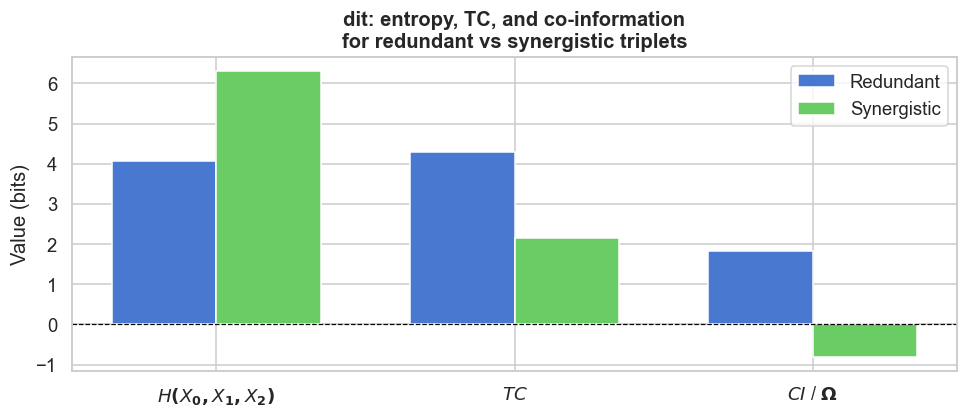

In [104]:
labels  = ['$H(X_0,X_1,X_2)$', '$TC$', '$CI$ / $\\Omega$']
vals_r  = [H_red,  TC_red,  CI_red]
vals_s  = [H_syn,  TC_syn,  CI_syn]

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, vals_r, w, label='Redundant',   color=sns.color_palette()[0])
ax.bar(x + w/2, vals_s, w, label='Synergistic', color=sns.color_palette()[2])
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Value (bits)')
ax.set_title('dit: entropy, TC, and co-information\nfor redundant vs synergistic triplets', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

---
## 6. Higher-Order Information with `hoi`

`hoi` captures a wide variety of information measures. Here we estimate O-information, TC, and DTC from **continuous** data using the KSG (Kozachenko–Leonenko) k-nearest-neighbour estimator (no binning needed).

The library sweeps all multiplets of a chosen size range and returns one
value per multiplet, making it easy to scan a dataset for synergistic or
redundant clusters.

> **Docs**: https://brainets.github.io/hoi/

Input shape: `(n_samples, n_features)`, note the transpose relative to our storage.

### 6.1 O-information

Positive $\Omega$ → redundancy-dominated; negative $\Omega$ → synergy-dominated.

In [105]:
# hoi expects (n_samples, n_features)
X_red = data_red.T   # (500, 3)
X_syn = data_syn.T   # (500, 3)

model_oinfo_red = Oinfo(X_red)
model_oinfo_syn = Oinfo(X_syn)

oinfo_red = model_oinfo_red.fit(minsize=3, maxsize=3)
oinfo_syn = model_oinfo_syn.fit(minsize=3, maxsize=3)

# .fit() returns an array; first (and only) element is the triplet value
omega_red = float(np.asarray(oinfo_red).ravel()[0])
omega_syn = float(np.asarray(oinfo_syn).ravel()[0])

print(f'O-information  Ω(X0,X1,X2)')
print(f'  Redundant:    {omega_red:+.4f}   ← POSITIVE ✓')
print(f'  Synergistic:  {omega_syn:+.4f}   ← NEGATIVE ✓')

    Copnorm and demean the data
Get list of multiplets
    Copnorm and demean the data                            
Get list of multiplets
                                                           

O-information  Ω(X0,X1,X2)
  Redundant:    +2.7946   ← POSITIVE ✓
  Synergistic:  -1.8679   ← NEGATIVE ✓


### 6.2 Total Correlation

In [53]:
model_tc_red = TC(X_red)
model_tc_syn = TC(X_syn)

tc_red = float(np.asarray(model_tc_red.fit(minsize=3, maxsize=3)).ravel()[0])
tc_syn = float(np.asarray(model_tc_syn.fit(minsize=3, maxsize=3)).ravel()[0])

print(f'Total Correlation  TC')
print(f'  Redundant:    {tc_red:.4f}')
print(f'  Synergistic:  {tc_syn:.4f}')

    Copnorm and demean the data
Get list of multiplets
    Copnorm and demean the data                         
Get list of multiplets
                                                        

Total Correlation  TC
  Redundant:    6.5718
  Synergistic:  2.8529


### 6.3 Dual Total Correlation

In [54]:
model_dtc_red = DTC(X_red)
model_dtc_syn = DTC(X_syn)

dtc_red = float(np.asarray(model_dtc_red.fit(minsize=3, maxsize=3)).ravel()[0])
dtc_syn = float(np.asarray(model_dtc_syn.fit(minsize=3, maxsize=3)).ravel()[0])

print(f'Dual Total Correlation  DTC')
print(f'  Redundant:    {dtc_red:.4f}')
print(f'  Synergistic:  {dtc_syn:.4f}')
print()
print('Verification: Ω = TC - DTC')
print(f'  Redundant:    {tc_red:.4f} - {dtc_red:.4f} = {tc_red - dtc_red:+.4f}'
      f'  (cf. direct Ω = {omega_red:+.4f})')
print(f'  Synergistic:  {tc_syn:.4f} - {dtc_syn:.4f} = {tc_syn - dtc_syn:+.4f}'
      f'  (cf. direct Ω = {omega_syn:+.4f})')

    Copnorm and demean the data
Get list of multiplets
    Copnorm and demean the data                          
Get list of multiplets
                                                         

Dual Total Correlation  DTC
  Redundant:    3.7991
  Synergistic:  4.7001

Verification: Ω = TC - DTC
  Redundant:    6.5718 - 3.7991 = +2.7727  (cf. direct Ω = +2.7727)
  Synergistic:  2.8529 - 4.7001 = -1.8472  (cf. direct Ω = -1.8472)


### 6.4 Summary visualisation

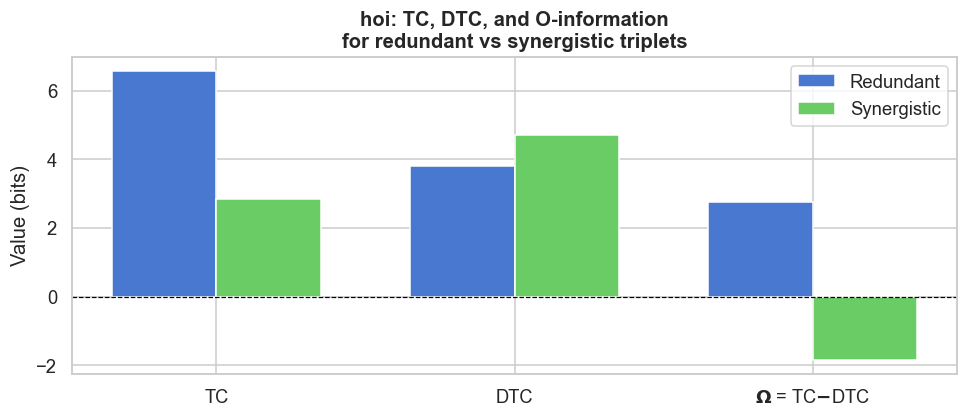

Key insight: TC is high in the redundant system (shared variance);
DTC is high in the synergistic system (many unique conditioning paths).


In [55]:
measures = ['TC', 'DTC', '$\\Omega$ = TC$-$DTC']
r_vals   = [tc_red, dtc_red, omega_red]
s_vals   = [tc_syn, dtc_syn, omega_syn]

x = np.arange(len(measures))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, r_vals, w, label='Redundant',   color=sns.color_palette()[0])
ax.bar(x + w/2, s_vals, w, label='Synergistic', color=sns.color_palette()[2])
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xticks(x); ax.set_xticklabels(measures, fontsize=12)
ax.set_ylabel('Value (bits)')
ax.set_title('hoi: TC, DTC, and O-information\nfor redundant vs synergistic triplets',
             fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

print('Key insight: TC is high in the redundant system (shared variance);')
print('DTC is high in the synergistic system (many unique conditioning paths).')

## 7. Scalable O-information with `thoi`

`thoi` computes the many of the same information measures as `hoi`, but is designed
to scale more efficiently to large systems.

The main difference is not the underlying information measure itself, but
how higher-order multiplets are searched and evaluated.

`hoi` evaluates a much larger set of variable combinations explicitly,
which becomes computationally expensive due to the combinatorial growth
of possible subsets.

`thoi` improves scalability using:

- **greedy / pruned search strategies** that avoid evaluating all multiplets,
- highly **vectorized PyTorch computations**,
- optional **GPU acceleration**.

This makes `thoi` substantially faster and capable of handling systems with
tens or hundreds of variables, at the cost of a less exhaustive exploration
of the interaction space.

| | `hoi` | `thoi` |
|--|-------|--------|
| Multiplet search | More exhaustive | Greedy / pruned |
| Scalability | Smaller systems | Large systems |
| Speed | Slower | Faster |
| GPU support | No | Yes (via PyTorch) |
| Coverage | Broader subset exploration | Approximate / selective |

.
> **Note**: `thoi` requires **PyTorch** as a backend.
> Install it with `conda install pytorch cpuonly -c pytorch` (CPU-only is sufficient).

> **Docs**: https://github.com/Laouen/THOI

`multi_order_measures(X, min_order, max_order)` takes `X` of shape
`(n_samples, n_features)` and returns a **DataFrame** with one row per multiplet
and columns `tc`, `dtc`, `o`, `s`, `order`, `var_0`, `var_1`, …

### 7.1 Artificial data — verification

In [56]:
# X_red and X_syn are (500, 3) — same arrays used for hoi above
df_thoi_red = multi_order_measures(X_red, min_order=3, max_order=3)
df_thoi_syn = multi_order_measures(X_syn, min_order=3, max_order=3)

print('Output is a DataFrame — one row per multiplet:')
print(df_thoi_red.to_string(index=False))
print()
print('Columns: tc (total correlation), dtc (dual TC), o (O-information),')
print('         s (S-information), order, var_0/var_1/var_2 (variable indices)')

Batch:   0%|          | 0/1 [00:00<?, ?it/s]

Output is a DataFrame — one row per multiplet:
 dataset       tc      dtc        o        s  var_0  var_1  var_2  order
       0 4.555247 2.633379 1.921868 7.188626   True   True   True      3

Columns: tc (total correlation), dtc (dual TC), o (O-information),
         s (S-information), order, var_0/var_1/var_2 (variable indices)


In [106]:
omega_thoi_red = float(df_thoi_red['o'].iloc[0])
omega_thoi_syn = float(df_thoi_syn['o'].iloc[0])

print(f'O-information  Ω(X0, X1, X2)')
print(f'  Redundant:    {omega_thoi_red:+.4f}   ← POSITIVE ✓')
print(f'  Synergistic:  {omega_thoi_syn:+.4f}   ← NEGATIVE ✓')

O-information  Ω(X0, X1, X2)
  Redundant:    +1.9219   ← POSITIVE ✓
  Synergistic:  -1.2804   ← NEGATIVE ✓


### 7.2 Comparison: `hoi` (KSG) vs `thoi` (Gaussian copula)

Because our artificial data is Gaussian by construction, both estimators
should agree closely. For real non-Gaussian data, they may diverge, which is itself informative.

In [111]:
print(f"{'Method':<22} {'Redundant':>12} {'Synergistic':>12}")
print('-' * 48)
print(f"{'dit  (exact plugin)':22} {CI_red:>+12.4f} {CI_syn:>+12.4f}")
print(f"{'hoi  (KSG)':22} {omega_red:>+12.4f} {omega_syn:>+12.4f}")
print(f"{'thoi (Gaussian copula)':22} {omega_thoi_red:>+12.4f} {omega_thoi_syn:>+12.4f}")
print()
print('All three methods agree on the sign.')
print('Magnitude differences reflect the different estimator assumptions.')

Method                    Redundant  Synergistic
------------------------------------------------
dit  (exact plugin)         +1.8320      -0.8135
hoi  (KSG)                  +2.7946      -1.8679
thoi (Gaussian copula)      +1.9219      -1.2804

All three methods agree on the sign.
Magnitude differences reflect the different estimator assumptions.


### 7.3 Information landscape: scaling to more variables

The real advantage of `thoi` is sweeping *all multiplets* across multiple orders
in one call. Here we build a 10-variable redundant system and plot the full
O-information landscape from order 2 to order 5.

With 10 variables, there are $\binom{10}{2}+\binom{10}{3}+\binom{10}{4}+\binom{10}{5} = 627$ multiplets.
Running `hoi` exhaustively on all of them would be impractical.

In [108]:
# Build a 10-variable redundant system
n_big  = 10
source = random.normal(0, 1, n_samples)
X_big  = np.column_stack([source + random.normal(0, 1, n_samples) * eta for _ in range(n_big)])  # shape: (500, 10)

# Sweep all multiplets from pairs (order 2) to 5-tuples (order 5)
df_big = multi_order_measures(X_big, min_order=2, max_order=5)
print(f'Total multiplets evaluated: {len(df_big)}')
print(df_big.groupby('order')['o'].describe().round(3))

Total multiplets evaluated: 627
       count   mean    std    min    25%    50%    75%    max
order                                                        
2       45.0 -0.000  0.000 -0.000 -0.000 -0.000 -0.000 -0.000
3      120.0  1.786  0.017  1.747  1.774  1.782  1.797  1.826
4      210.0  3.738  0.024  3.680  3.722  3.736  3.753  3.804
5      252.0  5.770  0.028  5.704  5.749  5.767  5.789  5.855


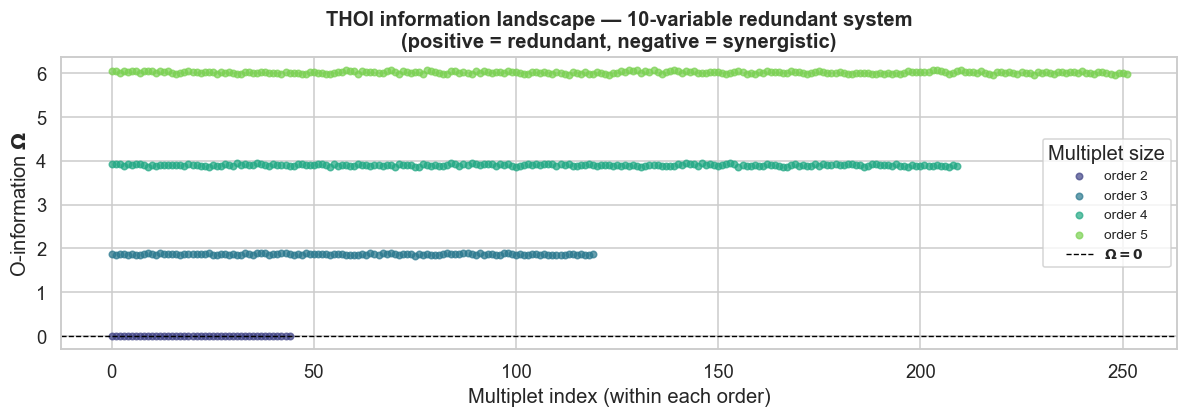

In [59]:
# Information landscape plot: one dot per multiplet, coloured by order
fig, ax = plt.subplots(figsize=(11, 4))
palette = sns.color_palette('viridis', n_colors=4)
for k, col in zip(range(2, 6), palette):
    subset = df_big[df_big['order'] == k].reset_index(drop=True)
    if subset.empty:
        continue
    ax.scatter(range(len(subset)), subset['o'],
               s=18, alpha=0.7, color=col, label=f'order {k}')
ax.axhline(0, color='black', lw=0.9, ls='--', label='$\\Omega = 0$')
ax.set_xlabel('Multiplet index (within each order)')
ax.set_ylabel('O-information $\\Omega$')
ax.set_title('THOI information landscape — 10-variable redundant system\n'
             '(positive = redundant, negative = synergistic)',
             fontweight='bold')
ax.legend(title='Multiplet size', fontsize=9)
plt.tight_layout()
plt.show()

---
## 8. Directed Information Flow with `pyinform`

`pyinform` focuses on **temporal** information structure.
Its key strength is computing *asymmetric* measures that reveal
the direction of information flow in time series.

> **Docs**: https://elife-asu.github.io/PyInform/

All `pyinform` functions operate on **lists of integers**.
We construct a simple causal binary system where the direction of
causation is known by construction, then verify that TE detects it.

### 8.1 A causal time series with memory and external driving

We construct a simple autoregressive binary process:

$$
Y_t =
\begin{cases}
Y_{t-1} & \text{with probability } 0.9 \\
X_{t-1} & \text{with probability } 0.1
\end{cases}
$$

Where:
- $X_t$ : independent Bernoulli process (no memory)
- $Y_t$ : mostly copies itself, occasionally updated from X

**Prediction**:
- $TE_{X\to Y} > 0$   (X occasionally drives Y)
- $TE_{Y\to X} \approx 0$   (Y does not influence X)
- $AIS(X)  \approx 0$   (X has no memory)
- $AIS(Y)$  high  (Y mostly persists)

In [129]:
T   = 500
rng = np.random.default_rng(SEED)

# X: independent fair coin
x = rng.integers(0, 2, size=T)

# Y: autoregressive + external drive
y = np.zeros(T, dtype=int)

# random initial condition
y[0] = rng.integers(0, 2)
p_self = 0.9

for t in range(1, T):
    # with high probability: keep previous state
    if rng.random() < p_self:
        y[t] = y[t-1]
    # otherwise: copy X
    else:
        y[t] = x[t-1]

print(f'Series length: {T}')
print(f'X sample: {x[:20].tolist()}...')
print(f'Y sample: {y[:20].tolist()}...')

Series length: 500
X sample: [0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0]...
Y sample: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]...


In [126]:
# Transfer Entropy
te_xy = transfer_entropy(x.tolist(), y.tolist(), k=1)
te_yx = transfer_entropy(y.tolist(), x.tolist(), k=1)

print('\nTransfer Entropy')
print(f'  TE(X→Y) = {te_xy:.4f} bits')
print(f'  TE(Y→X) = {te_yx:.4f} bits')
print(f'  ΔTE      = {te_xy - te_yx:.4f} bits')

# Active Information Storage
ais_x = active_info(x.tolist(), k=1)
ais_y = active_info(y.tolist(), k=1)

print('\nActive Information Storage')
print(f'  AIS(X) = {ais_x:.4f} bits')
print(f'  AIS(Y) = {ais_y:.4f} bits')


Transfer Entropy
  TE(X→Y) = 0.0558 bits
  TE(Y→X) = 0.0011 bits
  ΔTE      = 0.0547 bits

Active Information Storage
  AIS(X) = 0.0059 bits
  AIS(Y) = 0.6410 bits


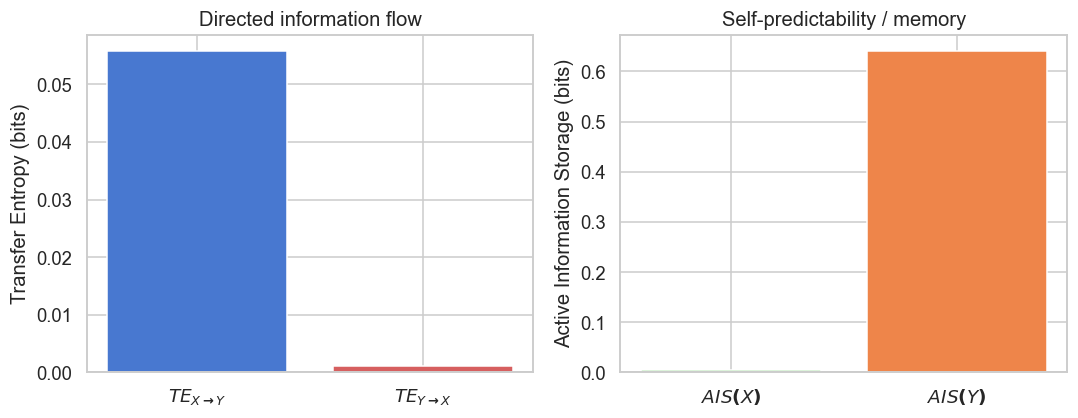

In [128]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# TE plot
axes[0].bar(['$TE_{X\\to Y}$', '$TE_{Y\\to X}$'], [te_xy, te_yx],
    color=[sns.color_palette()[0], sns.color_palette()[3]])
axes[0].set_ylabel('Transfer Entropy (bits)')
axes[0].set_title('Directed information flow')

# AIS plot
axes[1].bar(['$AIS(X)$', '$AIS(Y)$'], [ais_x, ais_y],
    color=[sns.color_palette()[2], sns.color_palette()[1]])
axes[1].set_ylabel('Active Information Storage (bits)')
axes[1].set_title('Self-predictability / memory')

plt.tight_layout()
plt.show()

---
## 9. Summary & Cross-Method Comparison

| Tool | Application | Estimator | Input |
|------|-------------------|-----------|-------|
| `dit` | Exact (co-)information for discrete distributions | Plugin PMF | Discrete |
| `hoi` | Higher-order O-info for continuous data (all multiplets) | KSG | Continuous |
| `thoi` | Same, scalable to large systems | Gaussian approx. | Continuous |
| `pyinform` | Directed information flow between time series | Plugin on bins | Discrete |

### Artificial data: O-information sign test (verification)

In [70]:
print(f'Redundant triplet  — expected Ω > 0')
print(f'  dit  (exact):     {CI_red:>+8.4f} bits')
print(f'  hoi  (KSG):       {omega_red:>+8.4f} bits')
print(f'  thoi (Gaussian):  {omega_thoi_red:>+8.4f} bits')
print()
print(f'Synergistic triplet — expected Ω < 0')
print(f'  dit  (exact):     {CI_syn:>+8.4f} bits')
print(f'  hoi  (KSG):       {omega_syn:>+8.4f} bits')
print(f'  thoi (Gaussian):  {omega_thoi_syn:>+8.4f} bits')

Redundant triplet  — expected Ω > 0
  dit  (exact):      +1.8993 bits
  hoi  (KSG):        +2.7727 bits
  thoi (Gaussian):   +1.9219 bits

Synergistic triplet — expected Ω < 0
  dit  (exact):      -1.0933 bits
  hoi  (KSG):        -1.8472 bits
  thoi (Gaussian):   -1.2804 bits


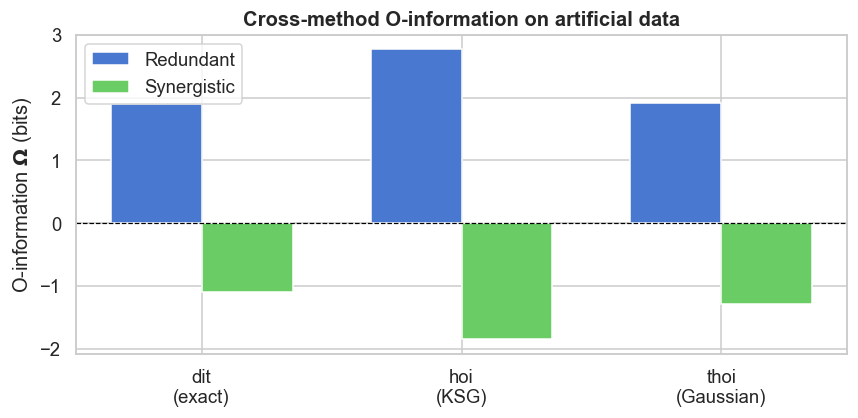


All three methods agree on the sign — redundant Ω>0, synergistic Ω<0.
Small numerical differences arise from the different estimator assumptions.


In [71]:
# Cross-method bar chart
methods = ['dit\n(exact)', 'hoi\n(KSG)', 'thoi\n(Gaussian)']
omega_r = [CI_red,  omega_red,  omega_thoi_red]
omega_s = [CI_syn,  omega_syn,  omega_thoi_syn]

x = np.arange(len(methods))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, omega_r, w, label='Redundant',   color=sns.color_palette()[0])
ax.bar(x + w/2, omega_s, w, label='Synergistic', color=sns.color_palette()[2])
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xticks(x); ax.set_xticklabels(methods)
ax.set_ylabel('O-information $\\Omega$ (bits)')
ax.set_title('Cross-method O-information on artificial data', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

print('\nAll three methods agree on the sign — redundant Ω>0, synergistic Ω<0.')
print('Small numerical differences arise from the different estimator assumptions.')

### Choosing a method in practice

| Scenario | Recommended tool |
|----------|-----------------|
| Small discrete dataset, exact computation needed | `dit` |
| Continuous data, ≤ ~20 variables | `hoi` |
| Continuous data, > 20 variables or GPU available | `thoi` |
| Time series, causal/directional questions | `pyinform` |

---
## 10. Real Data: The Wine Dataset

We now apply the same tools to a real dataset. The UCI Wine dataset contains
**178 samples** of Italian wines characterised by **13 chemical features**
(alcohol, malic acid, flavanoids, etc.) and a class label (1/2/3 = wine variety).

**Analysis plan:**
1. Load the data.
2. Use `sklearn`'s MI estimator for a fast pairwise relevance screening.
3. Apply `hoi` to the top features to detect higher-order structure.
4. Interpret what the O-information values mean about the chemical fingerprint
   of wine variety.

### 10.1 Load and explore

In [165]:
wine = load_wine()
X_wine = wine.data
y_wine = wine.target
feature_names = wine.feature_names

print(f'Shape: {X_wine.shape}  ({X_wine.shape[0]} samples, {X_wine.shape[1]} features)')
print(f'Classes: {np.unique(y_wine, return_counts=True)}')
print(f'Features: {feature_names}')

Shape: (178, 13)  (178 samples, 13 features)
Classes: (array([0, 1, 2]), array([59, 71, 48], dtype=int64))
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


### 10.2 Pairwise Mutual Information: feature relevance ranking

We first ask: which features individually carry the most information
about the wine class? `mutual_info_classif` uses a KSG estimator,
so no discretisation is needed here.

In [166]:
mi_scores = mutual_info_classif(X_wine, y_wine, random_state=SEED)
mi_df = pd.DataFrame({'feature': feature_names, 'MI': mi_scores})
mi_df = mi_df.sort_values('MI', ascending=False).reset_index(drop=True)

print('Feature ranking by Mutual Information with class label:')
print(mi_df.to_string(index=False))

Feature ranking by Mutual Information with class label:
                     feature       MI
                  flavanoids 0.667602
                     proline 0.577391
             color_intensity 0.548274
od280/od315_of_diluted_wines 0.516158
                     alcohol 0.474312
                         hue 0.466412
               total_phenols 0.401599
             proanthocyanins 0.305406
                  malic_acid 0.282384
           alcalinity_of_ash 0.237806
                   magnesium 0.213352
        nonflavanoid_phenols 0.120971
                         ash 0.079201


From this sorted list of features, let us select the 5 most influential ones to practice multivariate information analysis. Here we visualise and select the top 5 MI´s.

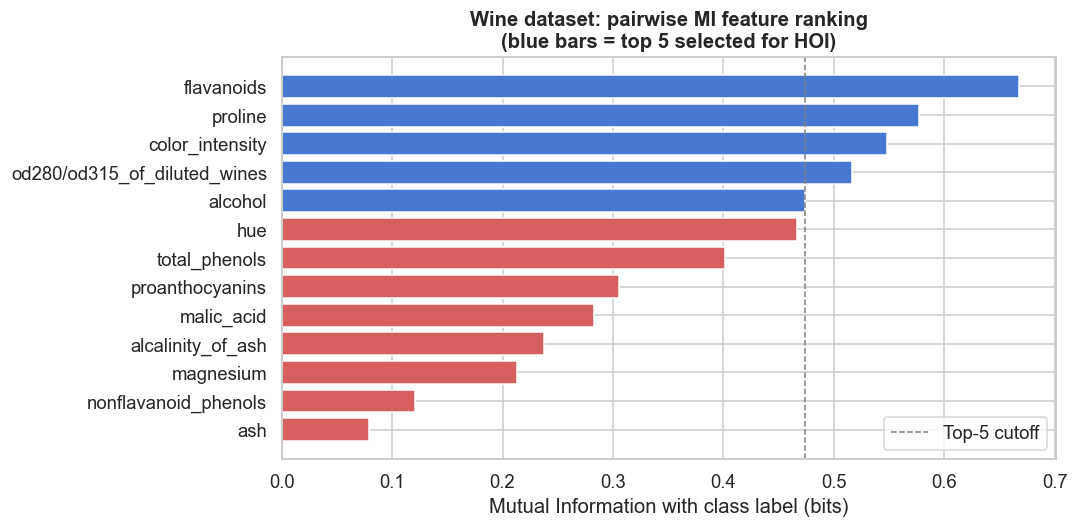


Top 5 features selected for higher-order analysis: ['flavanoids', 'proline', 'color_intensity', 'od280/od315_of_diluted_wines', 'alcohol']


In [167]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = [sns.color_palette()[0] if i < 5 else sns.color_palette('muted')[3]
          for i in range(len(mi_df))]
ax.barh(mi_df['feature'][::-1], mi_df['MI'][::-1], color=colors[::-1])
ax.axvline(mi_df['MI'].iloc[4], ls='--', lw=1, color='grey',
           label='Top-5 cutoff')
ax.set_xlabel('Mutual Information with class label (bits)')
ax.set_title('Wine dataset: pairwise MI feature ranking\n(blue bars = top 5 selected for HOI)',
             fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

top5 = mi_df['feature'].values[:5]
print(f'\nTop 5 features selected for higher-order analysis: {list(top5)}')

### 10.3 Higher-Order Analysis on the Top-5 Features

Now let us focus on the top-5 features that **individually** carry the most information about wine class.
We can ask which of these features carry more *redundant* information (e.g. two features that reflect the same underlying chemistry) or more *synergistic* information (features that are only jointly informative).
O-information sweeps all subsets and reveals this structure.

**Compute O-informations (top-5 features only)**

In [168]:
from itertools import combinations
import numpy as np

# Extract top-5 feature matrix
indices = [list(feature_names).index(f) for f in top5]
X_top5  = X_wine[:, indices]   # (178, 5)

# Compute O-information
model_wine = Oinfo(X_top5)
oinfo_wine = model_wine.fit(minsize=3, maxsize=5)

oinfo_arr = np.asarray(oinfo_wine).ravel()

print(f'Number of multiplets evaluated: {len(oinfo_arr)}')
print(f'O-information range: [{oinfo_arr.min():.4f}, {oinfo_arr.max():.4f}]')
print(f'Positive (redundant): {np.sum(oinfo_arr > 0)} / {len(oinfo_arr)}')
print(f'Negative (synergistic): {np.sum(oinfo_arr < 0)} / {len(oinfo_arr)}')

    Copnorm and demean the data
Get list of multiplets
                                                           

Number of multiplets evaluated: 16
O-information range: [-0.0996, 0.2274]
Positive (redundant): 10 / 16
Negative (synergistic): 6 / 16


**Identify most redundant and most synergistic multiplets**

In [170]:
n_features = X_top5.shape[1]
feature_list = list(top5)

# Reconstruct all feature combinations (same order as Oinfo output)
all_combos = []
for k in range(3, 6):
    all_combos += list(combinations(range(n_features), k))

# Build dataframe linking values to feature subsets
df = pd.DataFrame({"features_idx": all_combos, "o": oinfo_arr})
df["features"] = df["features_idx"].apply(lambda idxs: [feature_list[i] for i in idxs])

# Find extremes
max_row = df.loc[df["o"].idxmax()]
min_row = df.loc[df["o"].idxmin()]

print("Most REDUNDANT multiplet:")
print(max_row["features"], "Ω =", max_row["o"])

print("\nMost SYNERGISTIC multiplet:")
print(min_row["features"], "Ω =", min_row["o"])

Most REDUNDANT multiplet:
['flavanoids', 'proline', 'color_intensity', 'od280/od315_of_diluted_wines', 'alcohol'] Ω = 0.22742844

Most SYNERGISTIC multiplet:
['proline', 'color_intensity', 'od280/od315_of_diluted_wines'] Ω = -0.09962845


**Visualise O-information Distribution**

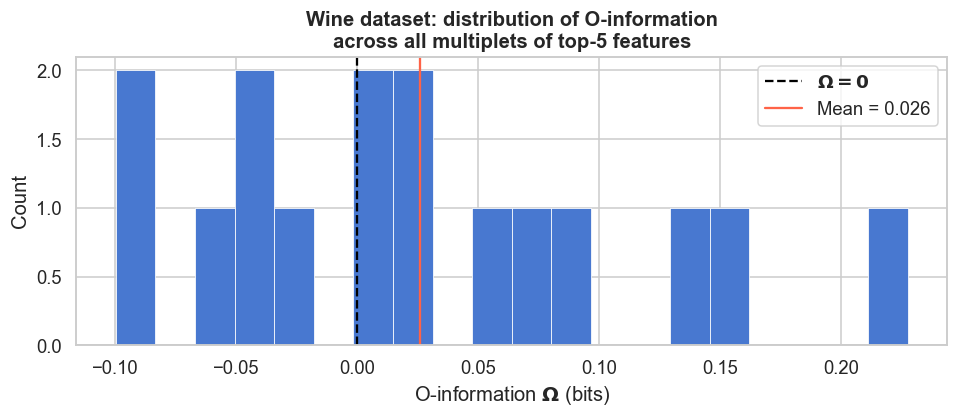

In [171]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(oinfo_arr, bins=20,
        color=sns.color_palette()[0],
        edgecolor='white', linewidth=0.5)

ax.axvline(0, color='black', lw=1.5, ls='--', label=r'$\Omega=0$')
ax.axvline(oinfo_arr.mean(), color='tomato', lw=1.5, ls='-',
           label=f'Mean = {oinfo_arr.mean():.3f}')

ax.set_xlabel(r'O-information $\Omega$ (bits)')
ax.set_ylabel('Count')
ax.set_title(
    'Wine dataset: distribution of O-information\n'
    'across all multiplets of top-5 features',
    fontweight='bold'
)

ax.legend()
plt.tight_layout()
plt.show()

### 10.5 Interpretation

The sign and distribution of O-information values describe the **information architecture** of the wine feature space: how chemical variables share, overlap, or complement each other. Mixed distributions are typical in real data and indicate coexisting redundant and synergistic feature groups.

It is also interesting to inspect the **extreme multiplets**:

- **Most redundant multiplet (highest $\Omega$)**:  
  These features carry largely overlapping information. They are driven by a common underlying factor, so each variable is partially predictable from the others.

- **Most synergistic multiplet (lowest $\Omega$)**:  
  These features are weak individually but informative jointly. The structure only emerges through their combination, indicating higher-order interactions in the chemical measurements.